# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Dytin Ba'Devia Az-Zahro
- **Email:** dytinbadeviaazzahro@gmail.com
- **ID Dicoding:** cdcc013d6x2754

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penyewaan sepeda berdasarkan musim (season)? Musim mana yang memiliki total penyewaan tertinggi?
- Bagaimana pola penyewaan sepeda pada jam-jam tertentu? Apakah ada perbedaan tren antara hari kerja (working day) dan hari libur (holiday)?


## Import Semua Packages/Library yang Digunakan

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [37]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [38]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day berisi agregasi jumlah penyewaan sepeda per hari.
- Setiap baris merepresentasikan satu tanggal pengamatan.
- Dataset day cocok digunakan untuk melihat tren harian, musiman, dan pengaruh cuaca terhadap jumlah rental.
- Dataset hour berisi agregasi jumlah penyewaan sepeda per jam.
- Setiap baris merepresentasikan satu jam pada tanggal tertentu.
- Dataset ini cocok untuk menganalisis pola penggunaan berdasarkan waktu, jam sibuk, serta perbedaan antara hari kerja dan akhir pekan.

### Assessing Data

In [25]:
day_df.info()
day_df.isnull().sum()


hour_df.info()
hour_df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [40]:
day_df.duplicated().sum()
day_df.duplicated().sum()

np.int64(0)

**Insight:**
- Tidak ditemukan missing values pada dataset day_df dan hour_df, sehingga data cukup lengkap untuk dianalisis lebih lanjut tanpa perlu proses pengisian nilai kosong (imputasi).
- Terdapat kesalahan tipe data pada kolom dteday, di mana kolom tersebut terdeteksi sebagai tipe data object (string), padahal seharusnya direpresentasikan sebagai tipe data datetime.
- Beberapa variabel kategorikal (seperti season, mnth, holiday, weekday, workingday, dan weathersit) masih tersimpan sebagai tipe data integer, yang nantinya perlu diperhatikan saat proses visualisasi agar interpretasinya tepat.

### Cleaning Data

In [26]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

**Insight:**
- Dilakukan konversi tipe data pada kolom dteday dari object menjadi datetime. Hal ini sangat penting agar kita bisa melakukan analisis berbasis waktu, seperti mengekstrak tren bulanan atau jam secara akurat.

- Tipe data pada kedua DataFrame (day_df dan hour_df) kini sudah konsisten dan siap digunakan untuk proses eksplorasi serta visualisasi tanpa kendala teknis pada variabel waktu.

## Exploratory Data Analysis (EDA)

### Explore ...

In [41]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [28]:
hour_df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


**Insight:**
- ## **day_df**
  - Rata-rata penyewaan sepeda per hari (cnt) adalah 4.504 unit.
  - Jumlah penyewaan harian terendah 22 unit dan tertinggi 8.714 unit.
  - Pengguna registered (3.656) jauh lebih banyak dibanding casual (848) per hari.
  - Variasi penyewaan cukup besar, menandakan permintaan berubah tergantung waktu atau kondisi tertentu.
- ## **hour_df**
  - Rata-rata penyewaan sepeda per jam (cnt) adalah 189 unit.
  - Penyewaan per jam terendah 1 unit dan tertinggi 977 unit.
  - Rata-rata pengguna registered (154) lebih dominan dibanding casual (36) per jam.
  - Perbedaan jumlah rental antar jam cukup tinggi, menunjukkan adanya jam sibuk dan jam sepi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh musim dan cuaca terhadap jumlah penyewaan sepeda?

/tmp/ipykernel_566/275505760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='cnt', data=day_df, estimator=sum, palette='viridis')


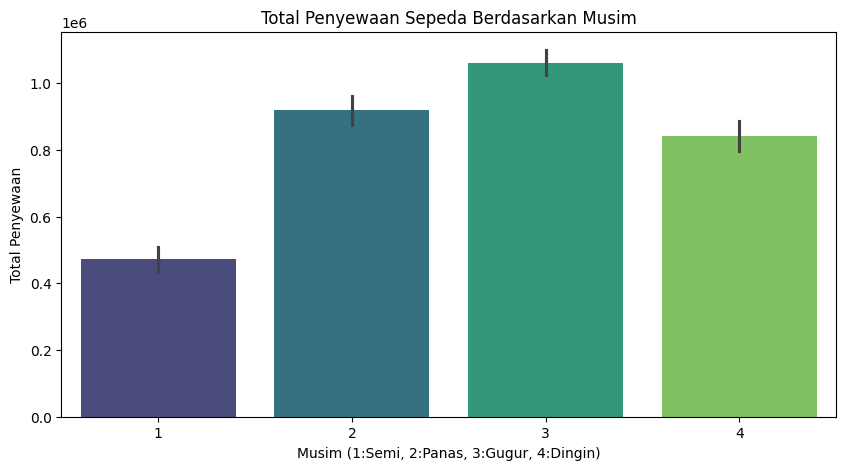

In [43]:
plt.figure(figsize=(10, 5))
sns.barplot(x='season', y='cnt', data=day_df, estimator=sum, palette='viridis')
plt.title('Total Penyewaan Sepeda Berdasarkan Musim')
plt.xlabel('Musim (1:Semi, 2:Panas, 3:Gugur, 4:Dingin)')
plt.ylabel('Total Penyewaan')
plt.show()

/tmp/ipykernel_566/3980691941.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_df, x="weathersit", y="cnt", palette='viridis')


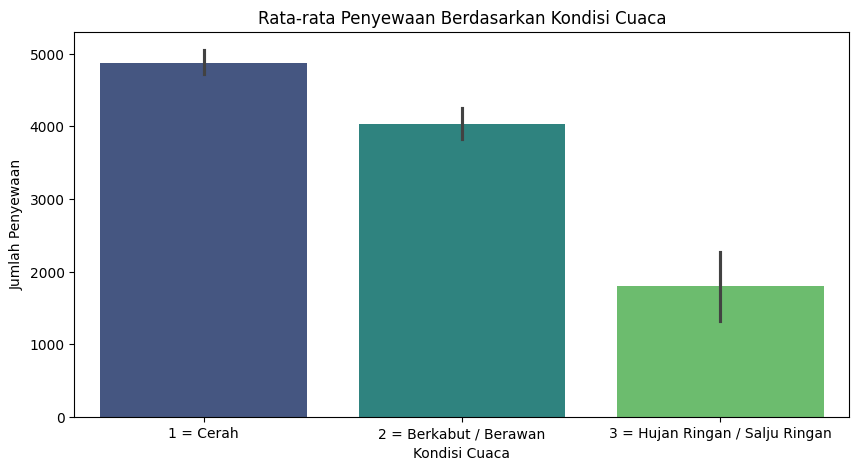

In [46]:
plt.figure(figsize=(10,5))
sns.barplot(data=day_df, x="weathersit", y="cnt", palette='viridis')

plt.title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Penyewaan")

plt.xticks(
    ticks=[0,1,2],
    labels=[
        "1 = Cerah",
        "2 = Berkabut / Berawan",
        "3 = Hujan Ringan / Salju Ringan"
    ]
)

plt.show()

**Insight**
- Grafik batang menunjukkan bahwa Musim Gugur (Fall/Season 3) adalah periode dengan jumlah penyewaan sepeda tertinggi secara akumulatif. Kondisi cuaca yang sejuk pada musim ini tampaknya sangat mendorong pengguna untuk beraktivitas menggunakan sepeda.
- Orang paling suka menyewa saat cuaca Cerah/Berawan (Weather 1). Begitu cuaca mulai Hujan/Berlubu (Weather 3), jumlah penyewa langsung anjlok drastis.

### Pertanyaan 2: Pada jam berapa penyewaan sepeda paling tinggi?

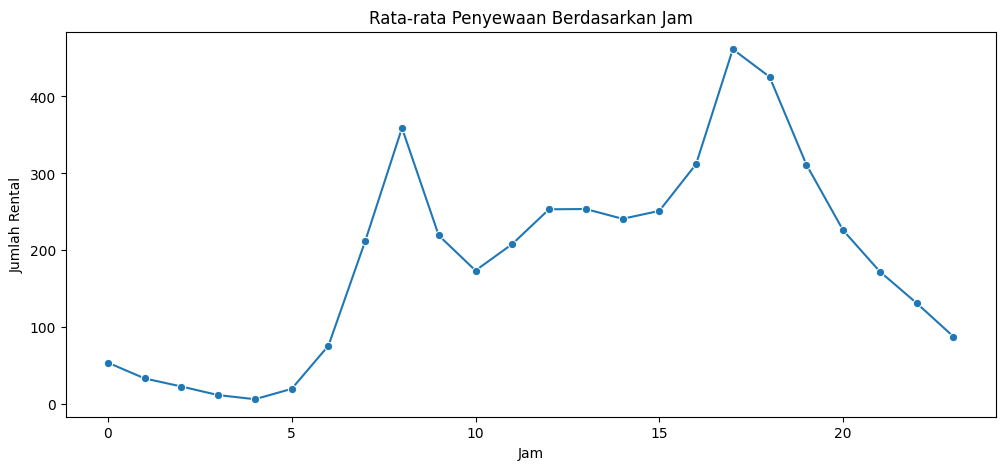

In [31]:
hourly_rent = hour_df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(12,5))
sns.lineplot(x=hourly_rent.index, y=hourly_rent.values, marker="o")
plt.title("Rata-rata Penyewaan Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Jumlah Rental")
plt.show()

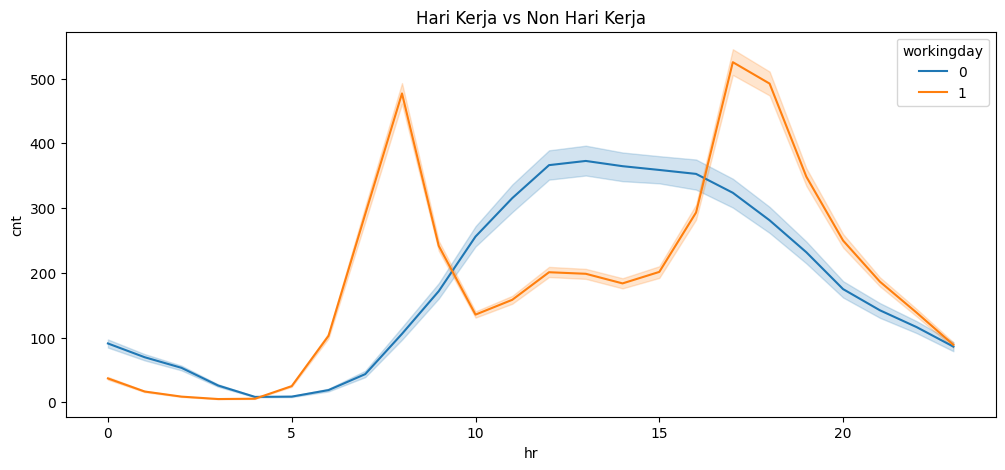

In [32]:
plt.figure(figsize=(12,5))
sns.lineplot(data=hour_df, x="hr", y="cnt", hue="workingday")
plt.title("Hari Kerja vs Non Hari Kerja")
plt.show()

**Insight:**
- Terdapat perbedaan pola yang kontras antara hari kerja (working day) dan hari libur. Pada hari kerja, grafik menunjukkan dua puncak (peak hours) yang tajam, yaitu pada pukul 08.00 pagi dan 17.00 sore. Ini menandakan bahwa mayoritas pengguna menggunakan sepeda sebagai sarana transportasi untuk berangkat dan pulang kerja.
- Ada dua lonjakan tajam dalam sehari, yaitu jam 08.00 pagi dan jam 17.00 - 18.00 sore. Ini jelas pola komuter (pergi dan pulang kantor).

## Analisis Lanjutan (Opsional)

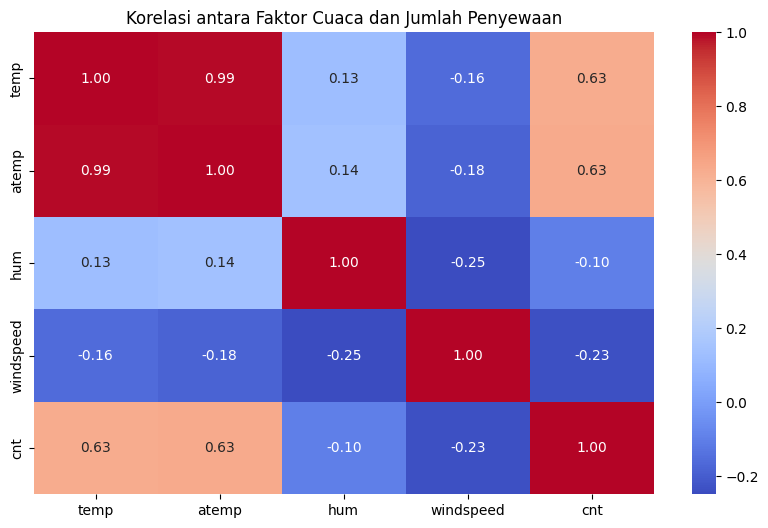

In [47]:
# Analisis Korelasi antara variabel numerik (cuaca) dan jumlah penyewaan
plt.figure(figsize=(10, 6))
correlation_matrix = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi antara Faktor Cuaca dan Jumlah Penyewaan')
plt.show()

**Insight**
- Variabel temp dan atemp memiliki korelasi positif cukup kuat terhadap jumlah penyewaan (cnt) sebesar 0.63. Artinya, semakin hangat suhu udara, jumlah penyewaan cenderung meningkat.
- Variabel hum memiliki korelasi negatif lemah terhadap cnt sebesar -0.10, menunjukkan kelembapan tinggi sedikit menurunkan minat penyewaan.

## Conclusion

- ## **Conclusion Pertanyaan 1**: Bagaimana pengaruh musim dan cuaca terhadap jumlah penyewaan sepeda?
  - Penyewaan bersifat musiman dengan puncak performa di Musim Gugur (Fall) dan titik terendah di Musim Semi (Springer). Strategi pemasaran harus digencarkan di awal tahun untuk menutupi rendahnya minat di musim tersebut
- ## **Conclusion Pertanyaan 2**: Pada jam berapa penyewaan sepeda paling tinggi?
  - Pola penggunaan sangat dipengaruhi oleh jam kerja. Lonjakan terjadi pada jam berangkat (08.00) dan jam pulang kantor (17.00-18.00) di hari kerja (workingday).